<a href="https://colab.research.google.com/github/00ayeshazahra/WWTP-Predictive-Maintainance/blob/main/Xylem_Pump_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [300]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [301]:
import pandas as pd
import glob
import os

TIME_COL = "Time (yyyy/mm/dd hh:mm:ss)"

def load_sensor_csvs(folder_path):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    df_list = []

    for file in csv_files:
        df = pd.read_csv(
            file,
            sep=';',
            decimal=',',
            header=8,
            usecols=[0, 1],
            parse_dates=[0],
            encoding='cp437'  # Read OEM United States encoding correctly
        )

        # Clean column names
        df.columns = (
            df.columns
            .str.replace(",+", "", regex=True)
            .str.strip()
        )

        # Safeguard for timestamp parsing
        df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

        # Replace negative error values with None
        df.iloc[:, 1] = df.iloc[:, 1].where(df.iloc[:, 1] >= 0, other=None)

        df_list.append(df)

    combined = pd.concat(df_list, ignore_index=True)

    # Remove invalid timestamps
    combined = combined.dropna(subset=[TIME_COL])

    # Sort chronologically
    combined = combined.sort_values(TIME_COL).reset_index(drop=True)

    return combined

In [302]:
import os

BASE_PATH = "/content/drive/MyDrive/Xylem Pump/Pump1/"

# Function to load and process a single CSV file
def _load_single_csv_file(file_name):
    full_file_path = os.path.join(BASE_PATH, file_name)
    df = pd.read_csv(
        full_file_path,
        sep=';',
        decimal=',',
        header=8,
        usecols=[0, 1],
        parse_dates=[0],
        encoding='cp437'
    )

    # Clean column names
    df.columns = (
        df.columns
        .str.replace(",+", "", regex=True)
        .str.strip()
    )

    # Safeguard for timestamp parsing
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

    # Replace negative error values with None
    df.iloc[:, 1] = df.iloc[:, 1].where(df.iloc[:, 1] >= 0, other=None)

    # Remove invalid timestamps
    df = df.dropna(subset=[TIME_COL])

    # Sort chronologically
    df = df.sort_values(TIME_COL).reset_index(drop=True)
    return df

# Pump current
current_df = _load_single_csv_file("PumpCurrent.csv")

# Frequency
frequency_df = _load_single_csv_file("Frequency.csv")

# Pump run
pump_run_df = _load_single_csv_file("PumpRun.csv")

# Pump duty rate
duty_rate_df = _load_single_csv_file("PumpDutyRate.csv")

# Starts per 24 hours
starts24h_df = _load_single_csv_file("Starts24h.csv")

# Main bearing temperature
main_bearing_temp_df = _load_single_csv_file("MainBearingTemp.csv")

# Stator phase temperature
stator_temp_df = _load_single_csv_file("StatorPhaseTemp.csv")

# Pump electronic module temperature
pem_temp_df = _load_single_csv_file("PumpElectronicModuleTemp.csv")

# Vibration X
vibration_x_df = _load_single_csv_file("VibrationX.csv")

# Vibration Y
vibration_y_df = _load_single_csv_file("VibrationY.csv")

# Vibration Z
vibration_z_df = _load_single_csv_file("VibrationZ.csv")

# Merge all dataframes into a single combined_df
combined_df = current_df
dfs_to_merge = [
    frequency_df, pump_run_df, duty_rate_df, starts24h_df,
    main_bearing_temp_df, pem_temp_df,
    vibration_x_df, vibration_y_df, vibration_z_df
]

for df_to_merge in dfs_to_merge:
    combined_df = pd.merge(combined_df, df_to_merge, on=TIME_COL, how="outer")

# Sort combined_df by time
combined_df = combined_df.sort_values(TIME_COL).reset_index(drop=True)

print("All files loaded and combined successfully!")

# Define column names for plotting from SENSOR_COLS and other relevant columns
current_col = "Pump Current (A)"
frequency_col = "Frequency (Hz)"
pump_run_col = "Pump Run (h)"
duty_col = "Pump Duty Rate (%)"
starts_col = "Starts per 24h"
bearing_col = "Main Bearing Temp (°C)"
pem_col = "PEM Temp (°C)"
vib_x_col = "Vibration X (mm/s)"
vib_y_col = "Vibration Y (mm/s)"
vib_z_col = "Vibration Z (mm/s)"

All files loaded and combined successfully!


In [303]:
def _load_single_csv_file(filename, base_path="/content/drive/MyDrive/Xylem Pump/Pump1/"):

    file_path = os.path.join(base_path, filename)

    df = pd.read_csv(
        file_path,
        sep=';',
        decimal=',',
        header=8,
        usecols=[0, 1],
        parse_dates=[0],
        encoding='cp437'
    )

    # Clean column names
    df.columns = (
        df.columns
        .str.replace(",+", "", regex=True)
        .str.strip()
    )

    # Safeguard for timestamp parsing
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

    # Replace negative error values with None
    df.iloc[:, 1] = df.iloc[:, 1].where(df.iloc[:, 1] >= 0, other=None)

    # Remove invalid timestamps
    df = df.dropna(subset=[TIME_COL])

    # Sort chronologically
    df = df.sort_values(TIME_COL).reset_index(drop=True)

    print(f"Loaded {filename}: {len(df)} rows")

    return df

In [304]:
correlation_table = combined_df.corr(method="pearson")
correlation_table.round(3)

,Time (yyyy/mm/dd hh:mm:ss),3531.766-2386020:Pump current (A),3531.766-2386020:Frequency (Hz),3531.766-2386020:Pump run (Binary),3531.766-2386020:Pump duty rate (7 day average) (%),3531.766-2386020:Starts/24 h (7 day average) (Binary),3531.766-2386020:Main bearing (┬░C),3531.766-2386020:Pump electronic module (┬░C),3531.766-2386020:Vibration X (radial perpendicular to cable entry) (mm/s),3531.766-2386020:Vibration Y (radial towards cable entry) (mm/s),3531.766-2386020:Vibration Z (axial) (mm/s)
Time (yyyy/mm/dd hh:mm:ss),1.000,0.128,0.086,-0.007,-0.044,0.056,0.024,0.018,-0.094,0.171,-0.091
3531.766-2386020:Pump current (A),0.128,1.000,0.990,0.405,0.223,0.072,0.531,0.537,0.397,0.355,0.296
3531.766-2386020:Frequency (Hz),0.086,0.990,1.000,0.469,0.261,0.043,0.581,0.588,0.372,0.335,0.304
3531.766-2386020:Pump run (Binary),-0.007,0.405,0.469,1.000,0.546,0.210,0.935,0.876,0.105,0.008,0.210
3531.766-2386020:Pump duty rate (7 day average) (%),-0.044,0.223,0.261,0.546,1.000,0.320,0.533,0.528,0.149,0.016,0.364
3531.766-2386020:Starts/24 h (7 day average) (Binary),0.056,0.072,0.043,0.210,0.320,1.000,0.198,0.140,0.113,-0.099,0.215
3531.766-2386020:Main bearing (┬░C),0.024,0.531,0.581,0.935,0.533,0.198,1.000,0.978,0.204,0.127,0.309
3531.766-2386020:Pump electronic module (┬░C),0.018,0.537,0.588,0.876,0.528,0.140,0.978,1.000,0.244,0.190,0.337
3531.766-2386020:Vibration X (radial perpendicular to cable entry) (mm/s),-0.094,0.397,0.372,0.105,0.149,0.113,0.204,0.244,1.000,0.616,0.644
3531.766-2386020:Vibration Y (radial towards cable entry) (mm/s),0.171,0.355,0.335,0.008,0.016,-0.099,0.127,0.190,0.616,1.000,0.630


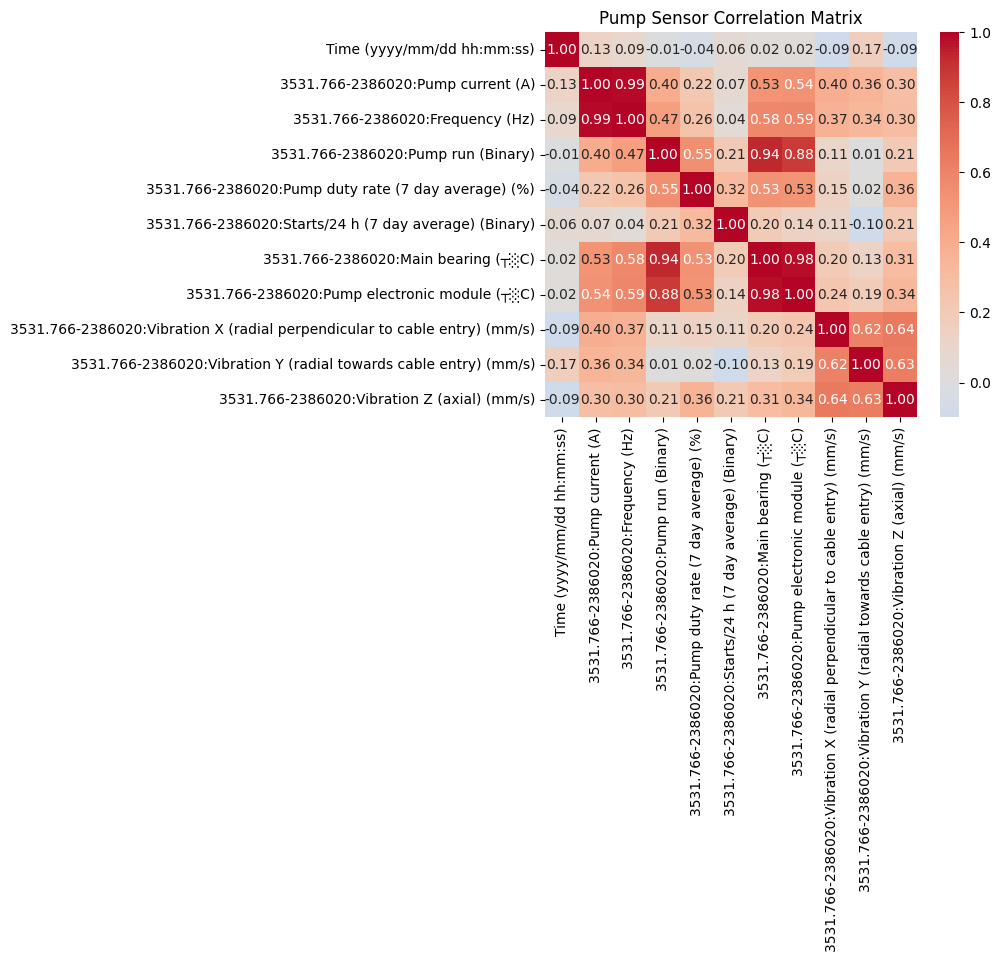

In [305]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    correlation_table,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Pump Sensor Correlation Matrix")
plt.show()

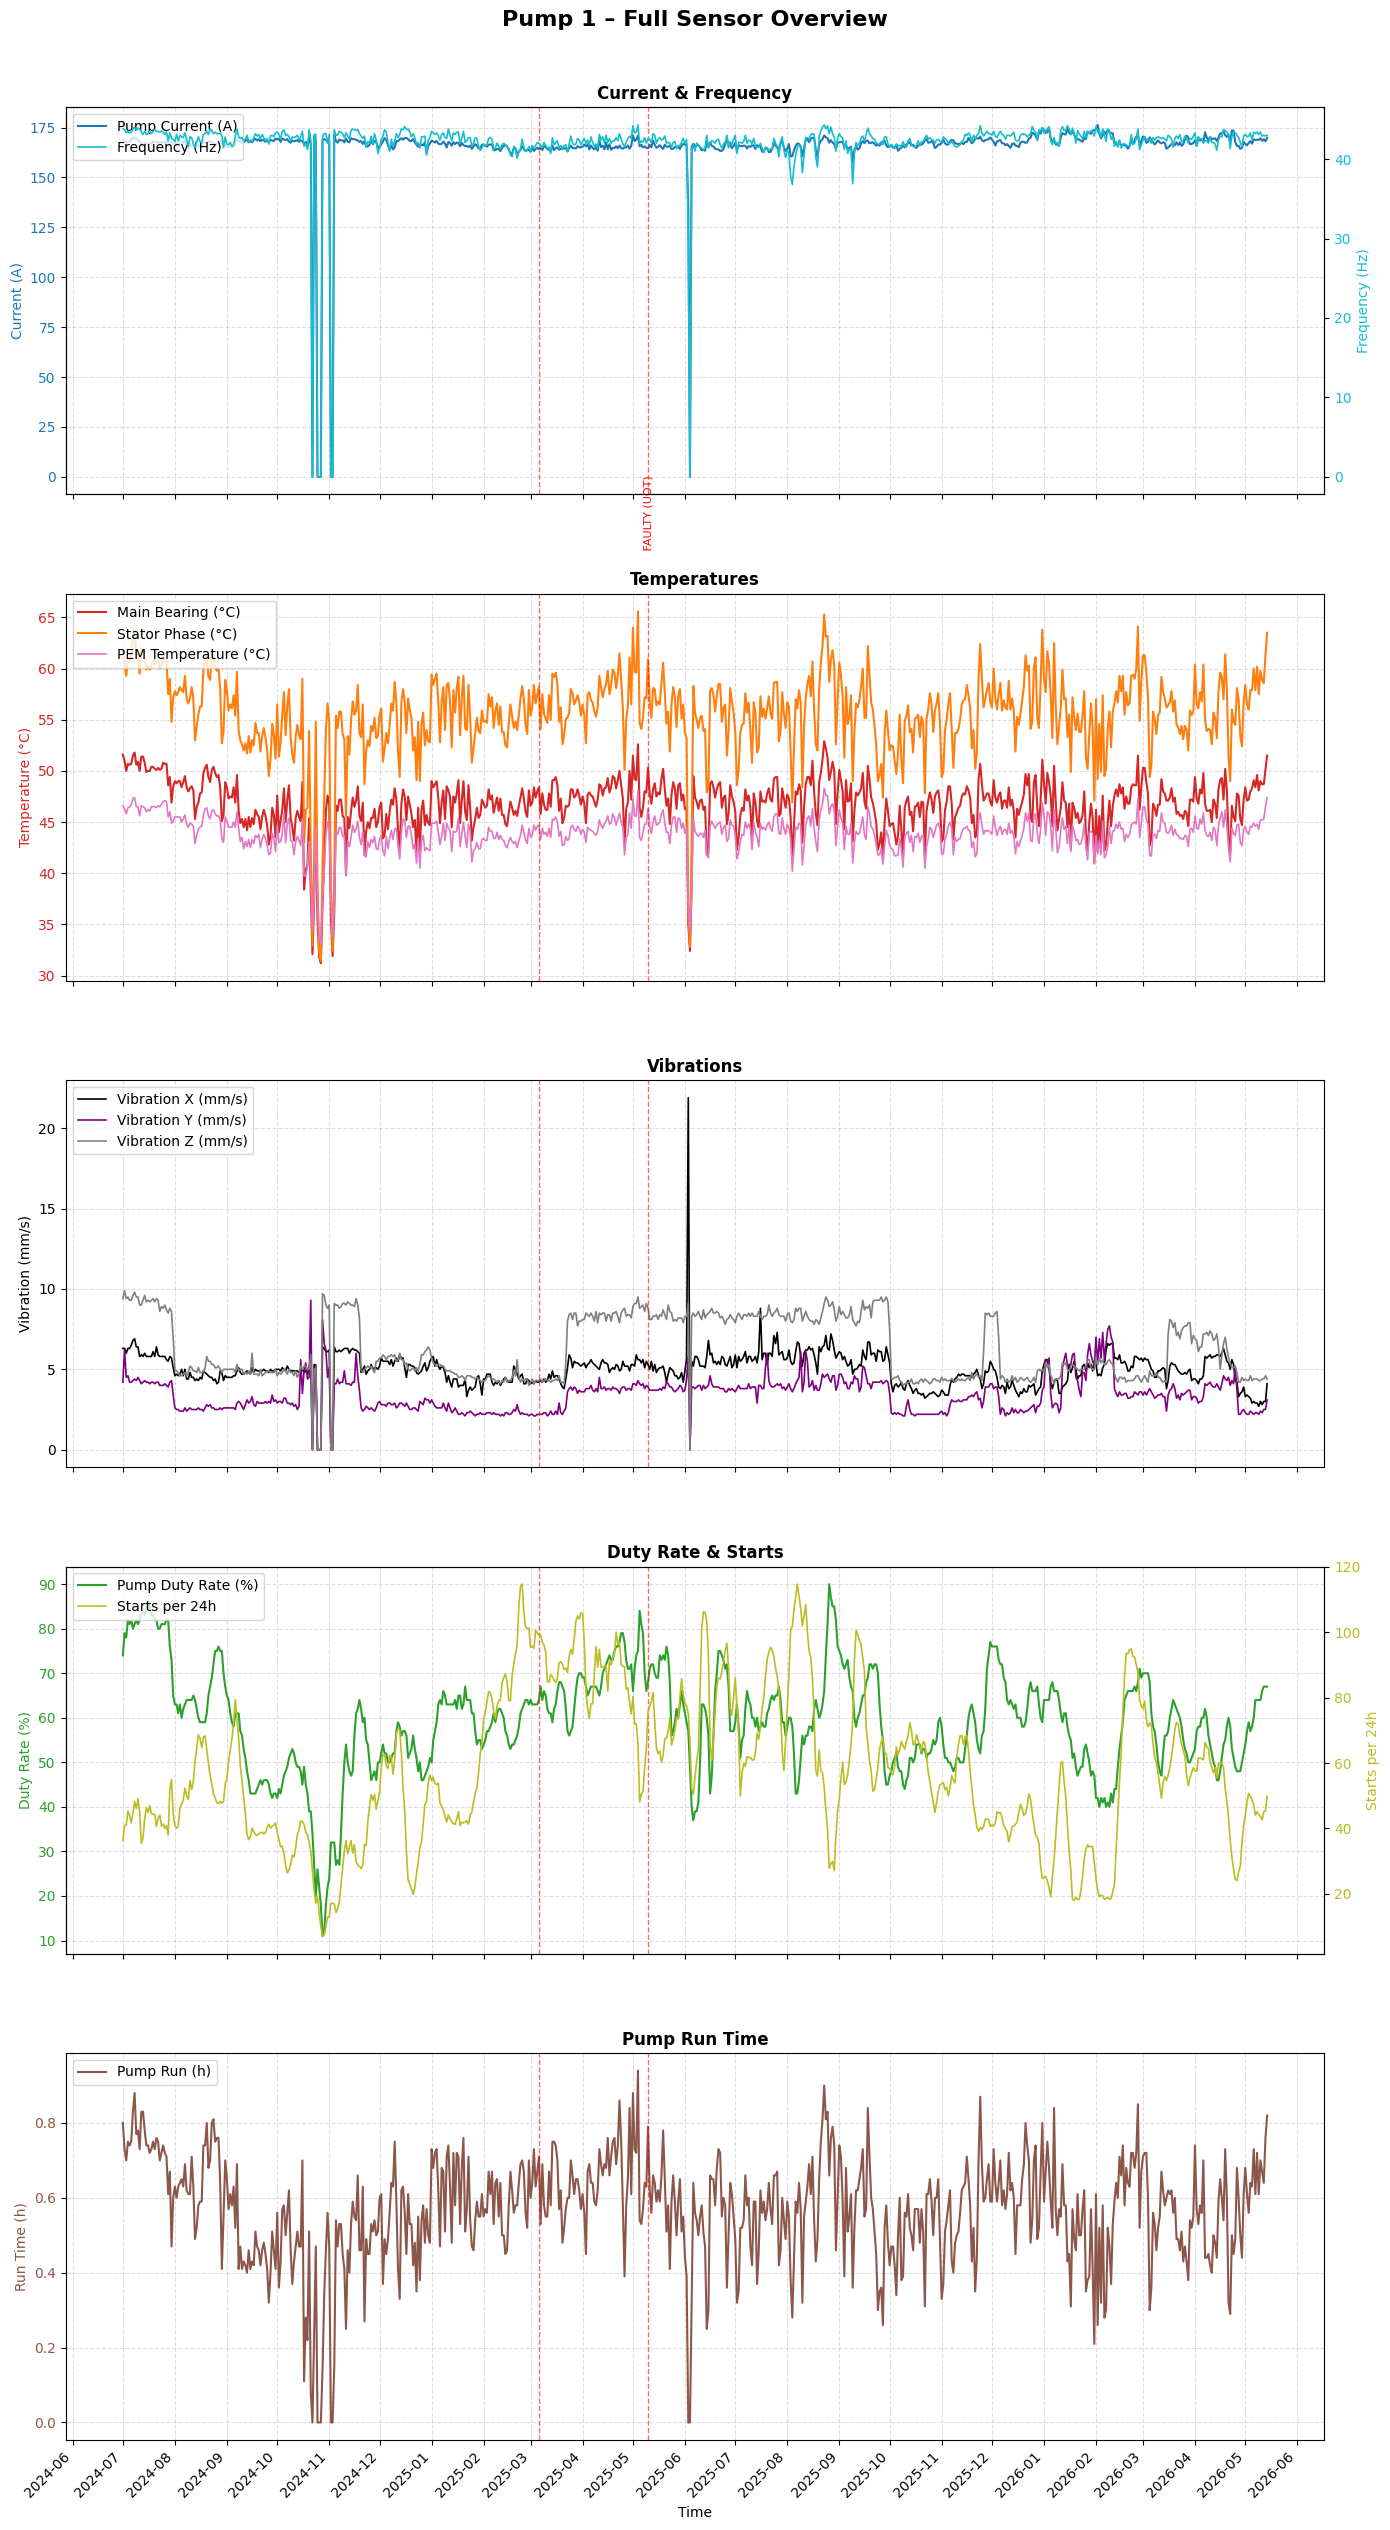

In [306]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime
# Import pandas

# Assuming TIME_COL is already defined from a previous cell, but re-defining for self-containment
TIME_COL = "Time (yyyy/mm/dd hh:mm:ss)"

events = [
    {"date": datetime(2025, 3, 6), "label": "MOTOR FAILURE-SHORTED",     "color": "red"},
    {"date": datetime(2025, 5, 10), "label": "FAULTY (UOT)",     "color": "red"},
    #{"date": datetime(2024, 9, 5),  "label": "Frequency spike",   "color": "orange"},
]


# List of all dataframes and their desired new column names for merging
dfs_to_merge = [
    (current_df, "Pump Current (A)"),
    (frequency_df, "Frequency (Hz)"),
    (pump_run_df, "Pump Run (h)"),
    (duty_rate_df, "Pump Duty Rate (%)"),
    (starts24h_df, "Starts per 24h"),
    (main_bearing_temp_df, "Main Bearing Temp (°C)"),
    (stator_temp_df, "Stator Phase Temp (°C)"),
    (pem_temp_df, "PEM Temp (°C)"),
    (vibration_x_df, "Vibration X (mm/s)"),
    (vibration_y_df, "Vibration Y (mm/s)"),
    (vibration_z_df, "Vibration Z (mm/s)")
]

# Initialize combined_df with the first dataframe, renaming its sensor column
initial_df, initial_col_name = dfs_to_merge[0]
combined_df = initial_df.rename(columns={initial_df.columns[1]: initial_col_name})

# Merge the rest of the dataframes
for df, col_name in dfs_to_merge[1:]:
    # Rename the sensor column in the current df to be merged
    df_renamed = df.rename(columns={df.columns[1]: col_name})
    # Merge with combined_df on TIME_COL using an outer join to keep all timestamps
    combined_df = pd.merge(combined_df, df_renamed, on=TIME_COL, how="outer")

# Ensure TIME_COL is sorted and unique
combined_df = combined_df.sort_values(TIME_COL).drop_duplicates(subset=[TIME_COL]).reset_index(drop=True)

# --- Dynamic column selection using the new descriptive names ---
current_col   = "Pump Current (A)"
bearing_col   = "Main Bearing Temp (°C)"
stator_col    = "Stator Phase Temp (°C)"
pem_col       = "PEM Temp (°C)"
vib_x_col     = "Vibration X (mm/s)"
vib_y_col     = "Vibration Y (mm/s)"
vib_z_col     = "Vibration Z (mm/s)"
frequency_col = "Frequency (Hz)"
duty_col      = "Pump Duty Rate (%)"
starts_col    = "Starts per 24h"
pump_run_col  = "Pump Run (h)"

fig, axes = plt.subplots(5, 1, figsize=(14, 25), sharex=True)

for event in events:
    for ax in axes:
        ax.axvline(
            x=event["date"],
            color=event["color"],
            linestyle="--",
            linewidth=1.0,
            alpha=0.6,
            zorder=3
        )

axes[0].text(
    event["date"],
    axes[0].get_ylim()[1],
    f" {event['label']}",
    fontsize=8,
    color=event["color"],
    rotation=90,
    va="top",
    ha="center"
    )

# --- Plot 1: Current & Frequency ---
ax1 = axes[0]
ax1_twin = ax1.twinx()

line1, = ax1.plot(
    combined_df[TIME_COL], combined_df[current_col],
    color="tab:blue", linewidth=1.5, label="Pump Current (A)"
)
line2, = ax1_twin.plot(
    combined_df[TIME_COL], combined_df[frequency_col],
    color="tab:cyan", linewidth=1.2, label="Frequency (Hz)"
)
ax1.set_ylabel("Current (A)", color="tab:blue")
ax1_twin.set_ylabel("Frequency (Hz)", color="tab:cyan")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1_twin.tick_params(axis="y", labelcolor="tab:cyan")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.set_title("Current & Frequency", fontweight="bold")
lines = [line1, line2]
ax1.legend(lines, [l.get_label() for l in lines], loc="upper left")

# --- Plot 2: Temperatures ---
ax2 = axes[1]
ax2.plot(
    combined_df[TIME_COL], combined_df[bearing_col],
    color="tab:red", linewidth=1.5, label="Main Bearing (°C)"
)
ax2.plot(
    combined_df[TIME_COL], combined_df[stator_col],
    color="tab:orange", linewidth=1.5, label="Stator Phase (°C)"
)
ax2.plot(
    combined_df[TIME_COL], combined_df[pem_col],
    color="tab:pink", linewidth=1.2, label="PEM Temperature (°C)"
)
ax2.set_ylabel("Temperature (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.set_title("Temperatures", fontweight="bold")
ax2.legend(loc="upper left")

# --- Plot 3: Vibrations ---
ax3 = axes[2]
ax3.plot(
    combined_df[TIME_COL], combined_df[vib_x_col],
    color="black", linewidth=1.2, label="Vibration X (mm/s)"
)
ax3.plot(
    combined_df[TIME_COL], combined_df[vib_y_col],
    color="purple", linewidth=1.2, label="Vibration Y (mm/s)"
)
ax3.plot(
    combined_df[TIME_COL], combined_df[vib_z_col],
    color="gray", linewidth=1.2, label="Vibration Z (mm/s)"
)
ax3.set_ylabel("Vibration (mm/s)")
ax3.grid(True, linestyle="--", alpha=0.4)
ax3.set_title("Vibrations", fontweight="bold")
ax3.legend(loc="upper left")

# --- Plot 4: Pump Duty Rate & Starts ---
ax4 = axes[3]
ax4_twin = ax4.twinx()

line3, = ax4.plot(
    combined_df[TIME_COL], combined_df[duty_col],
    color="tab:green", linewidth=1.5, label="Pump Duty Rate (%)"
)
line4, = ax4_twin.plot(
    combined_df[TIME_COL], combined_df[starts_col],
    color="tab:olive", linewidth=1.2, label="Starts per 24h"
)
ax4.set_ylabel("Duty Rate (%)", color="tab:green")
ax4_twin.set_ylabel("Starts per 24h", color="tab:olive")
ax4.tick_params(axis="y", labelcolor="tab:green")
ax4_twin.tick_params(axis="y", labelcolor="tab:olive")
ax4.grid(True, linestyle="--", alpha=0.4)
ax4.set_title("Duty Rate & Starts", fontweight="bold")
lines = [line3, line4]
ax4.legend(lines, [l.get_label() for l in lines], loc="upper left")

# --- Plot 5: Pump Run ---
ax5 = axes[4]
ax5.plot(
    combined_df[TIME_COL], combined_df[pump_run_col],
    color="tab:brown", linewidth=1.5, label="Pump Run (h)"
)
ax5.set_ylabel("Run Time (h)", color="tab:brown")
ax5.tick_params(axis="y", labelcolor="tab:brown")
ax5.grid(True, linestyle="--", alpha=0.4)
ax5.set_title("Pump Run Time", fontweight="bold")
ax5.legend(loc="upper left")

# --- X-axis formatting (applied to bottom plot only since sharex=True) ---
ax5.set_xlabel("Time")
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax5.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha="right")

# --- Overall title ---
fig.suptitle(
    "Pump 1 – Full Sensor Overview",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

In [307]:
import stumpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import warnings
warnings.filterwarnings("ignore")

print(f"stumpy version: {stumpy.__version__}")

SENSOR_COLS = [
    "Main Bearing Temp (°C)",
    "Stator Phase Temp (°C)",
    "PEM Temp (°C)",
    "Vibration X (mm/s)",
    "Vibration Y (mm/s)",
    "Vibration Z (mm/s)",
    "Pump Current (A)",
    "Frequency (Hz)",
    "Pump Duty Rate (%)",
]

# ── Alarm limits from your monitoring system (Image 2) ──────────────────────
LIMITS = {
    "Pump Current (A)":        {"high": 257.4, "very_high": 280.8},
    "Main Bearing Temp (°C)":  {"high": 80,    "very_high": 95},
    "Stator Phase Temp (°C)":  {"high": 120,   "very_high": 140},
    "PEM Temp (°C)":           {"high": 60,    "very_high": 80},
    "Vibration X (mm/s)":      {"high": 15,    "very_high": 25},
    "Vibration Y (mm/s)":      {"high": 15,    "very_high": 25},
    "Vibration Z (mm/s)":      {"high": 15,    "very_high": 25},
    "Pump Duty Rate (%)":      {"high": 100},
    "Starts per 24h":          {"high": 30},
}

# ── Drop rows where ANY sensor is NaN so all profiles share the same index ──
mp_df = combined_df[[TIME_COL] + SENSOR_COLS].dropna().reset_index(drop=True)

# ── Convert TIME_COL to datetime if not already ──────────────────────────────
mp_df[TIME_COL] = pd.to_datetime(mp_df[TIME_COL])

# ── Sampling frequency check ─────────────────────────────────────────────────
time_diffs = mp_df[TIME_COL].diff().dropna()
median_freq = time_diffs.median()
print(f"Median sampling interval : {median_freq}")
print(f"Total rows after dropna  : {len(mp_df)}")
print(f"Date range               : {mp_df[TIME_COL].iloc[0]} → {mp_df[TIME_COL].iloc[-1]}")


stumpy version: 1.13.0
Median sampling interval : 1 days 00:00:00
Total rows after dropna  : 683
Date range               : 2024-07-01 00:00:00 → 2026-05-14 00:00:00


In [308]:
# Matrix Profile
# Window = roughly 7 days of data.
# Adjust WINDOW_ROWS to match your actual sampling rate:
#   e.g. 1 reading/hour  → 7*24 = 168
#        1 reading/15min → 7*96 = 672
#        1 reading/day   → 7

WINDOW_ROWS = 7   # ← adjust this to your sampling rate

print(f"Window size: {WINDOW_ROWS} rows")
print("Computing per-sensor matrix profiles...")

per_sensor_mp = {}
for col in SENSOR_COLS:
    series = mp_df[col].values.astype(float)
    mp_result = stumpy.stump(series, m=WINDOW_ROWS)
    per_sensor_mp[col] = mp_result[:, 0]   # distance profile only
    print(f"  ✓ {col}")

# ── Multivariate profile across all sensors simultaneously ───────────────────
print("\nComputing multivariate profile (mSTAMP)...")
data_matrix = mp_df[SENSOR_COLS].values.T.astype(float)
# shape: (n_sensors, n_timepoints)

mp_multi, ip_multi = stumpy.mstump(data_matrix, m=WINDOW_ROWS)
# mp_multi shape: (n_sensors, n_timepoints - m + 1)
# Sum across sensors for a single combined anomaly score
combined_profile = mp_multi.sum(axis=0)

print("  ✓ Multivariate profile complete")
print(f"\nProfile length: {len(combined_profile)} points")

# ── Normalise combined profile to 0-1 for easy thresholding ─────────────────
profile_norm = (combined_profile - combined_profile.min()) / \
               (combined_profile.max() - combined_profile.min())

# ── Timestamps aligned to profile length ────────────────────────────────────
# Matrix profile output is shorter than input by (window - 1)
profile_times = mp_df[TIME_COL].values[:len(combined_profile)]

# ── Threshold: flag anything above mean + 2σ ────────────────────────────────
THRESHOLD_SIGMA = 2.0
mean_p = combined_profile.mean()
std_p  = combined_profile.std()
threshold = mean_p + THRESHOLD_SIGMA * std_p
threshold_norm = (threshold - combined_profile.min()) / \
                 (combined_profile.max() - combined_profile.min())

# ── Find top discords (most anomalous windows) ───────────────────────────────
N_DISCORDS = 10
discord_indices = np.argsort(combined_profile)[-N_DISCORDS:][::-1]
discord_times   = profile_times[discord_indices]

print(f"\nTop {N_DISCORDS} anomalous windows:")
for rank, (idx, t) in enumerate(zip(discord_indices, discord_times)):
    t_str = pd.Timestamp(t).strftime("%Y-%m-%d")
    print(f"  #{rank+1}  {t_str}  (score: {combined_profile[idx]:.2f})")

Window size: 7 rows
Computing per-sensor matrix profiles...
  ✓ Main Bearing Temp (°C)
  ✓ Stator Phase Temp (°C)
  ✓ PEM Temp (°C)
  ✓ Vibration X (mm/s)
  ✓ Vibration Y (mm/s)
  ✓ Vibration Z (mm/s)
  ✓ Pump Current (A)
  ✓ Frequency (Hz)
  ✓ Pump Duty Rate (%)

Computing multivariate profile (mSTAMP)...
  ✓ Multivariate profile complete

Profile length: 677 points

Top 10 anomalous windows:
  #1  2024-08-02  (score: 16.87)
  #2  2026-02-01  (score: 16.77)
  #3  2024-09-28  (score: 16.38)
  #4  2025-01-17  (score: 16.24)
  #5  2024-08-01  (score: 16.09)
  #6  2026-02-02  (score: 15.83)
  #7  2024-09-27  (score: 15.78)
  #8  2025-03-05  (score: 15.57)
  #9  2026-01-27  (score: 15.37)
  #10  2026-01-31  (score: 15.37)


In [309]:
# ── ISOLATION FOREST ────────────────────────────────────────────────────────
# Trains on the full dataset unsupervised.
# No window size needed — works on individual timestep feature vectors.
# Contamination = expected fraction of anomalies in the data (adjust 0.01–0.05)

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

CONTAMINATION = 0.05   # ← assume ~5% of readings are anomalous
N_DISCORDS    = 10
THRESHOLD_SIGMA = 2.0

print("Preparing features for Isolation Forest...")

# ── Feature matrix: all sensors at each timestep ─────────────────────────────
X = mp_df[SENSOR_COLS].values.astype(float)

# ── Standardise (IF is scale-sensitive across mixed units) ───────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Fit Isolation Forest ──────────────────────────────────────────────────────
print("Fitting Isolation Forest...")
iso = IsolationForest(
    n_estimators=200,        # more trees = more stable scores
    contamination=CONTAMINATION,
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
iso.fit(X_scaled)

# ── Score each timestep ───────────────────────────────────────────────────────
# decision_function returns: more negative = more anomalous
# We negate so that HIGH score = anomalous (consistent with Matrix Profile)
if_raw_scores  = -iso.decision_function(X_scaled)
if_labels      = iso.predict(X_scaled)   # -1 = anomaly, +1 = normal

# ── Normalise to 0-1 ─────────────────────────────────────────────────────────
if_norm = (if_raw_scores - if_raw_scores.min()) / \
          (if_raw_scores.max() - if_raw_scores.min())

# ── Timestamps (full length — IF operates per timestep, no window offset) ────
if_times = mp_df[TIME_COL].values

# ── Threshold ────────────────────────────────────────────────────────────────
mean_if   = if_raw_scores.mean()
std_if    = if_raw_scores.std()
threshold_if      = mean_if + THRESHOLD_SIGMA * std_if
threshold_if_norm = (threshold_if - if_raw_scores.min()) / \
                    (if_raw_scores.max() - if_raw_scores.min())

# ── Top anomalous timesteps ───────────────────────────────────────────────────
discord_indices_if = np.argsort(if_raw_scores)[-N_DISCORDS:][::-1]
discord_times_if   = if_times[discord_indices_if]

print(f"\nTop {N_DISCORDS} anomalous timesteps (Isolation Forest):")
for rank, (idx, t) in enumerate(zip(discord_indices_if, discord_times_if)):
    t_str = pd.Timestamp(t).strftime("%Y-%m-%d")
    print(f"  #{rank+1}  {t_str}  (score: {if_raw_scores[idx]:.4f})")

print(f"\nTotal flagged anomalies : {(if_labels == -1).sum()} / {len(if_labels)} timesteps")
print(f"Anomaly rate            : {(if_labels == -1).mean()*100:.1f}%")

Preparing features for Isolation Forest...
Fitting Isolation Forest...

Top 10 anomalous timesteps (Isolation Forest):
  #1  2024-10-27  (score: 0.2713)
  #2  2024-10-26  (score: 0.2615)
  #3  2024-10-25  (score: 0.2583)
  #4  2024-11-02  (score: 0.2580)
  #5  2025-06-04  (score: 0.2572)
  #6  2024-11-03  (score: 0.2567)
  #7  2024-10-22  (score: 0.2559)
  #8  2025-06-03  (score: 0.2145)
  #9  2024-10-28  (score: 0.1643)
  #10  2024-11-04  (score: 0.1268)

Total flagged anomalies : 35 / 683 timesteps
Anomaly rate            : 5.1%


In [310]:
# ── LSTM AUTOENCODER ─────────────────────────────────────────────────────────
# Learns "normal" temporal patterns from a rolling window.
# High reconstruction error = the pattern looks nothing like normal → anomaly.
# Requires tensorflow; install with: pip install tensorflow --quiet

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, RepeatVector,
                                     TimeDistributed, Dense)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

print(f"TensorFlow version: {tf.__version__}")

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
WINDOW_ROWS     = 7      # ← same as your Matrix Profile window
LATENT_DIM      = 32     # bottleneck size — smaller = stricter normal model
EPOCHS          = 50
BATCH_SIZE      = 64
VALIDATION_SPLIT= 0.1
THRESHOLD_SIGMA = 2.0
N_DISCORDS      = 10

# ─────────────────────────────────────────────────────────────────────────────
# 1. Scale features
# ─────────────────────────────────────────────────────────────────────────────
scaler_lstm = StandardScaler()
X_scaled = scaler_lstm.fit_transform(mp_df[SENSOR_COLS].values.astype(float))

n_timesteps = len(X_scaled)
n_features  = len(SENSOR_COLS)

# ─────────────────────────────────────────────────────────────────────────────
# 2. Build sliding windows  shape: (n_windows, WINDOW_ROWS, n_features)
# ─────────────────────────────────────────────────────────────────────────────
print("Building sliding windows...")

def make_windows(data, window):
    return np.stack([data[i:i+window] for i in range(len(data) - window + 1)])

X_windows = make_windows(X_scaled, WINDOW_ROWS)
print(f"  Windows shape: {X_windows.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. Build LSTM Autoencoder
# ─────────────────────────────────────────────────────────────────────────────
print("Building model...")

inp     = Input(shape=(WINDOW_ROWS, n_features))
encoded = LSTM(LATENT_DIM, activation="tanh", return_sequences=False)(inp)
decoded = RepeatVector(WINDOW_ROWS)(encoded)
decoded = LSTM(LATENT_DIM, activation="tanh", return_sequences=True)(decoded)
out     = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# ─────────────────────────────────────────────────────────────────────────────
# 4. Train (on all data — unsupervised, learns "normal" fingerprint)
# ─────────────────────────────────────────────────────────────────────────────
print("\nTraining LSTM Autoencoder...")
early_stop = EarlyStopping(monitor="val_loss", patience=5,
                           restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    X_windows, X_windows,          # input = target (reconstruction)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

# ─────────────────────────────────────────────────────────────────────────────
# 5. Reconstruction error per window = anomaly score
# ─────────────────────────────────────────────────────────────────────────────
print("\nScoring all windows...")
X_reconstructed = autoencoder.predict(X_windows, batch_size=BATCH_SIZE, verbose=0)

# Mean squared error per window
recon_errors = np.mean(np.square(X_windows - X_reconstructed), axis=(1, 2))

# ── Normalise ─────────────────────────────────────────────────────────────────
lstm_norm = (recon_errors - recon_errors.min()) / \
            (recon_errors.max() - recon_errors.min())

# ── Timestamps (offset by window − 1, same as Matrix Profile) ────────────────
lstm_times = mp_df[TIME_COL].values[:len(recon_errors)]

# ── Threshold ─────────────────────────────────────────────────────────────────
mean_re         = recon_errors.mean()
std_re          = recon_errors.std()
threshold_lstm  = mean_re + THRESHOLD_SIGMA * std_re
threshold_lstm_norm = (threshold_lstm - recon_errors.min()) / \
                      (recon_errors.max() - recon_errors.min())

# ── Top anomalous windows ──────────────────────────────────────────────────────
discord_indices_lstm = np.argsort(recon_errors)[-N_DISCORDS:][::-1]
discord_times_lstm   = lstm_times[discord_indices_lstm]

print(f"\nTop {N_DISCORDS} anomalous windows (LSTM Autoencoder):")
for rank, (idx, t) in enumerate(zip(discord_indices_lstm, discord_times_lstm)):
    t_str = pd.Timestamp(t).strftime("%Y-%m-%d")
    print(f"  #{rank+1}  {t_str}  (reconstruction error: {recon_errors[idx]:.6f})")

print(f"\nTotal flagged anomalies : {(recon_errors > threshold_lstm).sum()} windows")
print(f"Anomaly rate            : {(recon_errors > threshold_lstm).mean()*100:.1f}%")

TensorFlow version: 2.20.0
Building sliding windows...
  Windows shape: (677, 7, 9)
Building model...


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 7, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_15 (RepeatVector) │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 7, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 7, 9)           │           297 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,993 (54.66 KB)

 Trainable params: 13,993 (54.66 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM Autoencoder...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - loss: 1.0523 - val_loss: 0.3365
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.9369 - val_loss: 0.2992
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8359 - val_loss: 0.2682
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7499 - val_loss: 0.2440
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6987 - val_loss: 0.2275
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6593 - val_loss: 0.2197
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6329 - val_loss: 0.2170
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6111 - val_loss: 0.2122
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5922 - val_loss: 0.2055
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5751 - val_loss: 0.1992
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5607 - val_loss: 0.1939
Epoch 12/50
10/10 ━━━━━━━━━━━━━

In [311]:
# ── CUSUM & EWMA ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

EWMA_LAMBDA     = 0.1
CUSUM_K         = 0.5
THRESHOLD_SIGMA = 2.0
N_DISCORDS      = 10

print("Computing CUSUM & EWMA...")

scaler_spc = StandardScaler()
X_spc = scaler_spc.fit_transform(mp_df[SENSOR_COLS].values.astype(float))
n_steps, n_sensors = X_spc.shape

# ── EWMA ──────────────────────────────────────────────────────────────────────
ewma_scores = np.zeros((n_steps, n_sensors))
for j in range(n_sensors):
    z       = X_spc[:, j]
    ewma    = np.zeros(n_steps)
    ewma[0] = z[0]
    for i in range(1, n_steps):
        ewma[i] = EWMA_LAMBDA * z[i] + (1 - EWMA_LAMBDA) * ewma[i-1]
    sigma_ewma           = np.sqrt(EWMA_LAMBDA / (2 - EWMA_LAMBDA))
    ucl                  =  THRESHOLD_SIGMA * sigma_ewma
    lcl                  = -THRESHOLD_SIGMA * sigma_ewma
    ewma_scores[:, j]    = np.maximum(ewma - ucl, 0) + np.maximum(lcl - ewma, 0)

ewma_combined = ewma_scores.sum(axis=1)

# ── CUSUM ─────────────────────────────────────────────────────────────────────
cusum_scores = np.zeros((n_steps, n_sensors))
for j in range(n_sensors):
    z     = X_spc[:, j]
    S_pos = np.zeros(n_steps)
    S_neg = np.zeros(n_steps)
    for i in range(1, n_steps):
        S_pos[i]          = max(0, S_pos[i-1] + z[i] - CUSUM_K)
        S_neg[i]          = max(0, S_neg[i-1] - z[i] - CUSUM_K)
    cusum_scores[:, j]    = np.maximum(S_pos, S_neg)

cusum_combined = cusum_scores.sum(axis=1)

# ── Normalise & thresholds ────────────────────────────────────────────────────
def normalise(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

def norm_threshold(arr, sigma=THRESHOLD_SIGMA):
    t = arr.mean() + sigma * arr.std()
    return (t - arr.min()) / (arr.max() - arr.min() + 1e-9)

ewma_norm            = normalise(ewma_combined)
cusum_norm           = normalise(cusum_combined)
threshold_ewma_norm  = norm_threshold(ewma_combined)
threshold_cusum_norm = norm_threshold(cusum_combined)
spc_times            = mp_df[TIME_COL].values

# ── Top discords ──────────────────────────────────────────────────────────────
def top_discords(raw, times, n=N_DISCORDS):
    idx = np.argsort(raw)[-n:][::-1]
    return idx, times[idx]

discord_indices_ewma,  discord_times_ewma  = top_discords(ewma_combined,  spc_times)
discord_indices_cusum, discord_times_cusum = top_discords(cusum_combined, spc_times)

print("Top anomalous timesteps (EWMA):")
for rank, (idx, t) in enumerate(zip(discord_indices_ewma, discord_times_ewma)):
    print(f"  #{rank+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  (score: {ewma_combined[idx]:.4f})")

print("\nTop anomalous timesteps (CUSUM):")
for rank, (idx, t) in enumerate(zip(discord_indices_cusum, discord_times_cusum)):
    print(f"  #{rank+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  (score: {cusum_combined[idx]:.4f})")

print("\n✓ CUSUM & EWMA complete")

Computing CUSUM & EWMA...
Top anomalous timesteps (EWMA):
  #1  2024-10-27  (score: 14.9401)
  #2  2024-11-03  (score: 14.5731)
  #3  2024-10-28  (score: 14.2421)
  #4  2024-11-04  (score: 13.8332)
  #5  2024-10-29  (score: 13.1427)
  #6  2024-11-05  (score: 12.1735)
  #7  2024-10-30  (score: 11.6870)
  #8  2024-10-26  (score: 11.6655)
  #9  2024-11-02  (score: 11.4991)
  #10  2024-11-06  (score: 10.8393)

Top anomalous timesteps (CUSUM):
  #1  2024-11-04  (score: 327.3927)
  #2  2024-11-05  (score: 322.3556)
  #3  2024-11-03  (score: 321.6814)
  #4  2024-11-06  (score: 319.2895)
  #5  2024-11-07  (score: 314.7715)
  #6  2024-11-13  (score: 312.2040)
  #7  2024-11-14  (score: 311.7706)
  #8  2024-11-12  (score: 310.4487)
  #9  2024-11-08  (score: 309.8854)
  #10  2024-11-15  (score: 309.8657)

✓ CUSUM & EWMA complete


In [312]:
# ── REMAINING USEFUL LIFE (RUL) ───────────────────────────────────────────────
# LSTM regressor trained on labelled degradation windows before known events.
# Output: predicted days until next maintenance across the full timeline.
#
# Add more dates to MAINTENANCE_DATES as they accumulate — accuracy improves.

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

MAINTENANCE_DATES = [
    pd.Timestamp("2025-08-21"),
    # pd.Timestamp("YYYY-MM-DD"),  # add more here
]
DEGRADATION_DAYS = 90    # days before maintenance where RUL counts down
WINDOW_ROWS      = 7     # rolling input window — keep same as other models
EPOCHS           = 80
BATCH_SIZE       = 64
RUL_MAX          = DEGRADATION_DAYS
ALERT_RED        = 14    # days — urgent
ALERT_ORANGE     = 30    # days — warning

print(f"TensorFlow : {tf.__version__}")
print(f"Events     : {[str(d.date()) for d in MAINTENANCE_DATES]}")

# ── 1. Build RUL labels ───────────────────────────────────────────────────────
rul_labels = np.full(len(mp_df), float(RUL_MAX))
for maint_date in MAINTENANCE_DATES:
    window_start = maint_date - pd.Timedelta(days=DEGRADATION_DAYS)
    for i, ts in enumerate(mp_df[TIME_COL]):
        ts = pd.Timestamp(ts)
        if window_start <= ts <= maint_date:
            rul_labels[i] = min(rul_labels[i], float((maint_date - ts).days))

rul_labels_norm = rul_labels / RUL_MAX
print(f"Labelled degradation timesteps: {(rul_labels < RUL_MAX).sum()} / {len(rul_labels)}")

# ── 2. Scale features ─────────────────────────────────────────────────────────
scaler_rul = StandardScaler()
X_rul      = scaler_rul.fit_transform(mp_df[SENSOR_COLS].values.astype(float))

# ── 3. Sliding windows ────────────────────────────────────────────────────────
X_windows = np.stack([X_rul[i:i+WINDOW_ROWS] for i in range(len(X_rul) - WINDOW_ROWS + 1)])
y_windows = rul_labels_norm[WINDOW_ROWS - 1:]
rul_times = mp_df[TIME_COL].values[WINDOW_ROWS - 1:]

# ── 4. Train/test split on maintenance date ───────────────────────────────────
train_mask = pd.to_datetime(rul_times) < MAINTENANCE_DATES[0]
X_train, y_train = X_windows[train_mask],  y_windows[train_mask]
X_test,  y_test  = X_windows[~train_mask], y_windows[~train_mask]
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

# ── 5. Build model ────────────────────────────────────────────────────────────
inp = Input(shape=(WINDOW_ROWS, len(SENSOR_COLS)))
x   = LSTM(64, activation="tanh", return_sequences=True)(inp)
x   = Dropout(0.2)(x)
x   = LSTM(32, activation="tanh")(x)
x   = Dropout(0.2)(x)
x   = Dense(16, activation="relu")(x)
out = Dense(1,  activation="sigmoid")(x)

rul_model = Model(inp, out)
rul_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# ── 6. Train ──────────────────────────────────────────────────────────────────
print("\nTraining...")
history_rul = rul_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8,
                             restore_best_weights=True, verbose=1)],
    shuffle=True, verbose=1
)

# ── 7. Predict full timeline ──────────────────────────────────────────────────
rul_pred_norm = rul_model.predict(X_windows, batch_size=BATCH_SIZE, verbose=0).flatten()
rul_pred_days = rul_pred_norm * RUL_MAX

print(f"\nCurrent predicted RUL : {rul_pred_days[-1]:.1f} days")
print(f"Min predicted RUL     : {rul_pred_days.min():.1f} days  "
      f"({pd.Timestamp(rul_times[rul_pred_days.argmin()]).strftime('%Y-%m-%d')})")
print(f"Periods < {ALERT_RED}d  (urgent)  : {(rul_pred_days < ALERT_RED).sum()} timesteps")
print(f"Periods < {ALERT_ORANGE}d (warning) : {(rul_pred_days < ALERT_ORANGE).sum()} timesteps")
print("\n✓ RUL model complete")

TensorFlow : 2.20.0
Events     : ['2025-08-21']
Labelled degradation timesteps: 90 / 683
Train: 410  |  Test: 267

Training...
Epoch 1/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.2210 - mae: 0.4662 - val_loss: 0.0910 - val_mae: 0.2520
Epoch 2/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1780 - mae: 0.4153 - val_loss: 0.1301 - val_mae: 0.3067
Epoch 3/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1323 - mae: 0.3523 - val_loss: 0.1871 - val_mae: 0.3869
Epoch 4/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0838 - mae: 0.2738 - val_loss: 0.2451 - val_mae: 0.4583
Epoch 5/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0384 - mae: 0.1815 - val_loss: 0.2878 - val_mae: 0.5054
Epoch 6/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0118 - mae: 0.0985 - val_loss: 0.3171 - val_mae: 0.5354
Epoch 7/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0042 - mae: 0.0540 - val_loss: 0.3440 - val_mae: 0.5604
Epoch 8/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0023 - m

In [313]:
# ── STL DECOMPOSITION ─────────────────────────────────────────────────────────
# Separates each sensor into Trend + Seasonal + Residual.
# Residual = what's left after normal patterns are removed = clean anomaly signal.
# No labels, no training, no hyperparameters beyond the seasonal period.

from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler

THRESHOLD_SIGMA = 2.0
N_DISCORDS      = 10

# ── Seasonal period ───────────────────────────────────────────────────────────
# Set to the number of readings in one natural cycle.
# e.g. 1 reading/day  → weekly cycle = 7
#      1 reading/hour → weekly cycle = 7*24 = 168
STL_PERIOD = 7    # ← adjust to match your sampling rate

print(f"Running STL decomposition (period={STL_PERIOD})...")

stl_residuals  = {}   # raw residual per sensor
stl_trends     = {}   # trend component per sensor
stl_seasonal   = {}   # seasonal component per sensor

for col in SENSOR_COLS:
    series = mp_df[col].values.astype(float)
    # STL requires a clean series — fill any remaining NaNs with interpolation
    series = pd.Series(series).interpolate().ffill().bfill().values
    result = STL(series, period=STL_PERIOD, robust=True).fit()
    stl_residuals[col] = result.resid
    stl_trends[col]    = result.trend
    stl_seasonal[col]  = result.seasonal
    print(f"  ✓ {col}")

# ── Combined anomaly score: sum of squared residuals across all sensors ────────
residual_matrix  = np.column_stack([stl_residuals[c] for c in SENSOR_COLS])
# Standardise residuals so sensors with larger magnitudes don't dominate
residual_scaled  = residual_matrix / (residual_matrix.std(axis=0) + 1e-9)
stl_combined     = np.sum(residual_scaled ** 2, axis=1)

# ── Normalise ─────────────────────────────────────────────────────────────────
stl_norm      = (stl_combined - stl_combined.min()) / \
                (stl_combined.max() - stl_combined.min() + 1e-9)
stl_times     = mp_df[TIME_COL].values

mean_stl      = stl_combined.mean()
std_stl       = stl_combined.std()
threshold_stl = mean_stl + THRESHOLD_SIGMA * std_stl
threshold_stl_norm = (threshold_stl - stl_combined.min()) / \
                     (stl_combined.max() - stl_combined.min() + 1e-9)

# ── Top discords ──────────────────────────────────────────────────────────────
discord_indices_stl = np.argsort(stl_combined)[-N_DISCORDS:][::-1]
discord_times_stl   = stl_times[discord_indices_stl]

print(f"\nTop {N_DISCORDS} anomalous timesteps (STL):")
for rank, (idx, t) in enumerate(zip(discord_indices_stl, discord_times_stl)):
    print(f"  #{rank+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  "
          f"(score: {stl_combined[idx]:.4f})")

print("\n✓ STL decomposition complete")

Running STL decomposition (period=7)...
  ✓ Main Bearing Temp (°C)
  ✓ Stator Phase Temp (°C)
  ✓ PEM Temp (°C)
  ✓ Vibration X (mm/s)
  ✓ Vibration Y (mm/s)
  ✓ Vibration Z (mm/s)
  ✓ Pump Current (A)
  ✓ Frequency (Hz)
  ✓ Pump Duty Rate (%)

Top 10 anomalous timesteps (STL):
  #1  2025-06-04  (score: 510.6904)
  #2  2025-06-03  (score: 458.8447)
  #3  2024-11-03  (score: 428.8813)
  #4  2024-10-27  (score: 376.5781)
  #5  2024-10-22  (score: 370.2892)
  #6  2024-10-26  (score: 321.0439)
  #7  2024-11-02  (score: 317.2851)
  #8  2024-10-25  (score: 308.3094)
  #9  2024-11-10  (score: 84.9164)
  #10  2025-06-05  (score: 82.9908)

✓ STL decomposition complete


In [314]:
# ── CHANGE POINT DETECTION (PELT) ─────────────────────────────────────────────
# Finds where the statistical properties of the signal permanently shift.
# Unlike anomaly detection (spikes), this catches regime changes —
# e.g. post-maintenance operating at a different baseline, slow bearing
# degradation moving to a new mean level, or operational mode changes.
#
# Uses the PELT algorithm (Pruned Exact Linear Time) via the `ruptures` library.
# pip install ruptures --quiet

!pip install ruptures lifelines --quiet
import ruptures as rpt
import numpy as np # Explicitly import numpy

THRESHOLD_SIGMA  = 2.0
N_DISCORDS       = 10
N_BREAKPOINTS    = 10   # max number of change points to find across the timeline
                        # increase if you expect more regime shifts

print(f"ruptures version: {rpt.__version__}")
print("Running change point detection (PELT)...")

# ── Stack all sensors, standardise ────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
scaler_cp  = StandardScaler()
X_cp       = scaler_cp.fit_transform(mp_df[SENSOR_COLS].values.astype(float))
cp_times   = mp_df[TIME_COL].values

# ── PELT — multivariate, RBF cost function ────────────────────────────────────
# "rbf" cost is robust to outliers; "l2" is faster but more sensitive to spikes
algo    = rpt.Pelt(model="rbf", min_size=7, jump=1).fit(X_cp)
result  = algo.predict(pen=10)   # pen (penalty): higher = fewer breakpoints
                                 # lower = more breakpoints — tune to your data

# ruptures returns indices of the END of each segment (last index = len(signal))
raw_breakpoint_indices = np.array(result[:-1])   # drop the final boundary

# Check if breakpoint_indices is empty before clipping and indexing
if raw_breakpoint_indices.size == 0:
    breakpoint_indices = np.array([], dtype=int) # Assign an empty integer array
    breakpoint_times = np.array([], dtype='datetime64[ns]') # Assign an empty datetime array
    print("No change points detected with the current penalty. Consider lowering 'pen' value.")
else:
    # Ensure indices are integers before clipping and using them for indexing
    breakpoint_indices = raw_breakpoint_indices.astype(int)
    breakpoint_indices = np.clip(breakpoint_indices, 0, len(cp_times)-1)
    breakpoint_times   = cp_times[breakpoint_indices]

print(f"\nDetected {len(breakpoint_indices)} change points:")
for i, (idx, t) in enumerate(zip(breakpoint_indices, breakpoint_times)):
    print(f"  CP{i+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  (index: {idx})")

# ── Build a continuous "change intensity" score ────────────────────────────────
# For each timestep, score = distance to nearest change point (inverted).
# This gives a smooth signal for plotting alongside other models.
cp_score = np.ones(len(cp_times)) * len(cp_times)   # large default distance
for bp_idx in breakpoint_indices:
    distances       = np.abs(np.arange(len(cp_times)) - bp_idx)
    cp_score        = np.minimum(cp_score, distances)

# Invert so spikes appear AT change points
cp_score_inv  = cp_score.max() - cp_score

# Normalise
cp_norm       = (cp_score_inv - cp_score_inv.min()) / \
                (cp_score_inv.max() - cp_score_inv.min() + 1e-9)

threshold_cp_norm = 0.85   # fixed: only the immediate vicinity of change points

print(f"\n✓ Change point detection complete  ({len(breakpoint_indices)} breakpoints found)")
print("  Tip: adjust pen= (penalty) in algo.predict() if too many or too few are found.")

ruptures version: v1.1.10
Running change point detection (PELT)...

Detected 6 change points:
  CP1  2024-07-31  (index: 30)
  CP2  2024-09-08  (index: 69)
  CP3  2025-01-03  (index: 186)
  CP4  2025-03-23  (index: 265)
  CP5  2025-10-02  (index: 458)
  CP6  2025-11-13  (index: 500)

✓ Change point detection complete  (6 breakpoints found)
  Tip: adjust pen= (penalty) in algo.predict() if too many or too few are found.


In [315]:
# ── COX PROPORTIONAL HAZARDS ──────────────────────────────────────────────────
# Survival analysis model — predicts the instantaneous risk (hazard rate)
# of failure at each moment given current sensor readings.
#
# Key output:
#   - Hazard ratio per sensor: which sensors drive failure risk most
#   - Continuous risk score across the timeline
#   - Survival probability curve (probability pump survives to time T)
#
# pip install lifelines --quiet

import lifelines
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

THRESHOLD_SIGMA  = 2.0
N_DISCORDS       = 10

print(f"lifelines version: {lifelines.__version__}")

# ── Define failure events ──────────────────────────────────────────────────────
# For Cox PH we need (duration, event_observed) per observation window.
# Strategy: split timeline into rolling 30-day windows.
# A window "fails" if a maintenance event falls within it.

MAINTENANCE_DATES = [
    pd.Timestamp("2025-08-21"),
    # pd.Timestamp("YYYY-MM-DD"),  # add more here
]
WINDOW_DAYS = 30   # assessment window length

print(f"Maintenance events : {[str(d.date()) for d in MAINTENANCE_DATES]}")
print("Building survival dataset...")

# ── Build feature + label rows ────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler_cox = StandardScaler()
X_cox_raw  = mp_df[SENSOR_COLS].values.astype(float)
X_cox      = scaler_cox.fit_transform(X_cox_raw)
cox_times  = pd.to_datetime(mp_df[TIME_COL].values)

# Rolling window: every row is a 'subject' observed from that point forward
durations       = []
event_observed  = []

for i, t in enumerate(cox_times):
    # Duration = days until next maintenance event (or end of record)
    next_events = [d for d in MAINTENANCE_DATES if d > t]
    if next_events:
        next_event     = min(next_events)
        dur            = (next_event - t).days
        obs            = 1 if dur <= WINDOW_DAYS else 0
        dur            = min(dur, WINDOW_DAYS)
    else:
        dur            = WINDOW_DAYS
        obs            = 0
    durations.append(dur)
    event_observed.append(obs)

durations      = np.array(durations, dtype=float)
event_observed = np.array(event_observed, dtype=int)

# ── Build DataFrame for lifelines ─────────────────────────────────────────────
cox_df = pd.DataFrame(X_cox, columns=SENSOR_COLS)
cox_df["duration"] = durations
cox_df["event"]    = event_observed

# Remove zero-duration rows (lifelines requirement)
cox_df = cox_df[cox_df["duration"] > 0].reset_index(drop=True)

print(f"  Total rows    : {len(cox_df)}")
print(f"  Failure rows  : {cox_df['event'].sum()}")

# ── Fit Cox PH model ──────────────────────────────────────────────────────────
print("\nFitting Cox Proportional Hazards model...")
cph = CoxPHFitter(penalizer=0.1)   # L2 regularisation for stability
cph.fit(cox_df, duration_col="duration", event_col="event", show_progress=False)

print("\n── Hazard ratios (exp(coef)) — values > 1 increase failure risk ──────────")
cph.print_summary(decimals=3, style="ascii")

# ── Continuous risk score across the full timeline ────────────────────────────
print("\nScoring full timeline...")
cox_features   = pd.DataFrame(X_cox, columns=SENSOR_COLS)
log_hazard     = cph.predict_log_partial_hazard(cox_features).values
cox_risk_score = np.exp(log_hazard)   # partial hazard — higher = riskier

# Normalise
cox_norm       = (cox_risk_score - cox_risk_score.min()) / \
                 (cox_risk_score.max() - cox_risk_score.min() + 1e-9)
cox_plot_times = mp_df[TIME_COL].values

mean_cox            = cox_risk_score.mean()
std_cox             = cox_risk_score.std()
threshold_cox       = mean_cox + THRESHOLD_SIGMA * std_cox
threshold_cox_norm  = (threshold_cox - cox_risk_score.min()) / \
                      (cox_risk_score.max() - cox_risk_score.min() + 1e-9)

# ── Top high-risk timesteps ───────────────────────────────────────────────────
discord_indices_cox = np.argsort(cox_risk_score)[-N_DISCORDS:][::-1]
discord_times_cox   = cox_plot_times[discord_indices_cox]

print(f"\nTop {N_DISCORDS} highest-risk timesteps (Cox PH):")
for rank, (idx, t) in enumerate(zip(discord_indices_cox, discord_times_cox)):
    print(f"  #{rank+1}  {pd.Timestamp(t).strftime('%Y-%m-%d')}  "
          f"(hazard: {cox_risk_score[idx]:.4f})")

# ── Most influential sensors ───────────────────────────────────────────────────
coef_df = cph.params_.reset_index()
coef_df.columns = ["Sensor", "log_hazard_ratio"]
coef_df["hazard_ratio"] = np.exp(coef_df["log_hazard_ratio"])
coef_df = coef_df.sort_values("hazard_ratio", ascending=False)

print("\n── Sensor influence ranking (hazard ratio > 1 = increases risk) ───────────")
for _, row in coef_df.iterrows():
    direction = "↑ risk" if row["hazard_ratio"] > 1 else "↓ risk"
    print(f"  {row['Sensor']:<35} HR={row['hazard_ratio']:.3f}  {direction}")

print("\n✓ Cox Proportional Hazards complete")

lifelines version: 0.30.3
Maintenance events : ['2025-08-21']
Building survival dataset...
  Total rows    : 683
  Failure rows  : 30

Fitting Cox Proportional Hazards model...

── Hazard ratios (exp(coef)) — values > 1 increase failure risk ──────────
<lifelines.CoxPHFitter: fitted with 683 total observations, 653 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 683
number of events observed = 30
   partial log-likelihood = -186.508
         time fit was run = 2026-05-25 05:00:46 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Main Bearing Temp (°C)  0.072     1.075     0.109          -0.142           0.

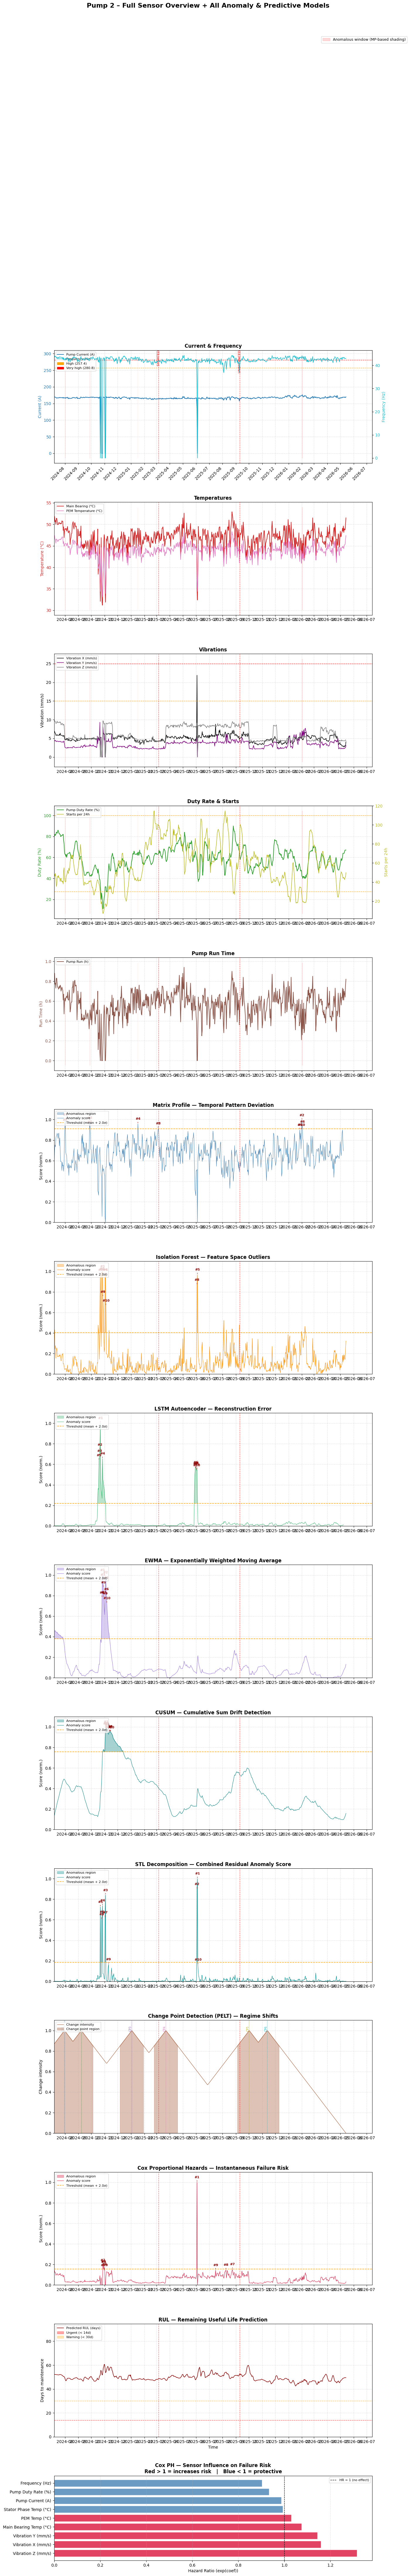

In [320]:
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────
def draw_limits(ax, col_name):
    if col_name not in LIMITS:
        return []
    handles, lims = [], LIMITS[col_name]
    if "high" in lims:
        ax.axhline(lims["high"], color="orange", linestyle="--",
                   linewidth=1.0, alpha=0.85, zorder=2)
        handles.append(mpatches.Patch(color="orange", label=f"High ({lims['high']})"))
    if "very_high" in lims:
        ax.axhline(lims["very_high"], color="red", linestyle="--",
                   linewidth=1.0, alpha=0.85, zorder=2)
        handles.append(mpatches.Patch(color="red", label=f"Very high ({lims['very_high']})"))
    return handles

def shade_anomalies(ax, times, score_norm, thresh_norm):
    ylo, yhi = ax.get_ylim()
    ax.fill_between(times, ylo, yhi,
                    where=(score_norm > thresh_norm),
                    color="red", alpha=0.07, zorder=0)

def draw_score_panel(ax, times, score_norm, thresh_norm,
                     disc_idx, disc_times, raw_scores, title, color):
    ax.fill_between(times, score_norm, thresh_norm,
                    where=(score_norm > thresh_norm),
                    color=color, alpha=0.35, label="Anomalous region")
    ax.plot(times, score_norm, color=color, linewidth=0.8, label="Anomaly score")
    ax.axhline(thresh_norm, color="orange", linestyle="--",
               linewidth=1.2, label=f"Threshold (mean + {THRESHOLD_SIGMA}σ)")
    for rank, (idx, t) in enumerate(zip(disc_idx, disc_times)):
        t_nv = (raw_scores[idx] - raw_scores.min()) / \
               (raw_scores.max() - raw_scores.min() + 1e-9)
        ax.annotate(f"#{rank+1}", xy=(t, t_nv), xytext=(0, 10),
                    textcoords="offset points", fontsize=8,
                    color="darkred", fontweight="bold", ha="center",
                    arrowprops=dict(arrowstyle="-", color="darkred", lw=0.8))
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score (norm.)")
    ax.set_title(title, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Events
# ─────────────────────────────────────────────────────────────────────────────
events = [
    {"date": datetime(2025, 3, 6), "label": "SHORTED", "color": "red"},
    {"date": datetime(2025, 9, 10), "label": "UNBALANCED",  "color": "red"},
]

# ─────────────────────────────────────────────────────────────────────────────
# Build figure: 14 time-series rows + 1 bar chart row
# ─────────────────────────────────────────────────────────────────────────────
N_TS   = 14
fig    = plt.figure(figsize=(14, 7 * N_TS))
gs     = gridspec.GridSpec(N_TS + 1, 1, figure=fig,
                           height_ratios=[1]*N_TS + [0.75],
                           hspace=0.35)

ts_axes = [fig.add_subplot(gs[i]) for i in range(N_TS)]
ax_bar  = fig.add_subplot(gs[N_TS])   # bar chart — no shared x

# Share x-axis across all time-series panels
for ax in ts_axes[1:]:
    ax.sharex(ts_axes[0])

# ── Event lines across all time-series panels ─────────────────────────────────
for event in events:
    for ax in ts_axes:
        ax.axvline(x=event["date"], color=event["color"],
                   linestyle="--", linewidth=1.0, alpha=0.6, zorder=3)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 1: Current & Frequency
# ─────────────────────────────────────────────────────────────────────────────
ax1      = ts_axes[0]
ax1_twin = ax1.twinx()
line1, = ax1.plot(combined_df[TIME_COL], combined_df[current_col],
                  color="tab:blue", linewidth=1.5, label="Pump Current (A)")
line2, = ax1_twin.plot(combined_df[TIME_COL], combined_df[frequency_col],
                       color="tab:cyan", linewidth=1.2, label="Frequency (Hz)")
ax1.set_ylabel("Current (A)", color="tab:blue")
ax1_twin.set_ylabel("Frequency (Hz)", color="tab:cyan")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1_twin.tick_params(axis="y", labelcolor="tab:cyan")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.set_title("Current & Frequency", fontweight="bold")
lim_handles = draw_limits(ax1, current_col)
ax1.legend([line1, line2] + lim_handles,
           [h.get_label() for h in [line1, line2] + lim_handles],
           loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 2: Temperatures
# ─────────────────────────────────────────────────────────────────────────────
ax2 = ts_axes[1]
ax2.plot(combined_df[TIME_COL], combined_df[bearing_col],
         color="tab:red",  linewidth=1.5, label="Main Bearing (°C)")
ax2.plot(combined_df[TIME_COL], combined_df[pem_col],
         color="tab:pink", linewidth=1.2, label="PEM Temperature (°C)")
ax2.set_ylabel("Temperature (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.set_title("Temperatures", fontweight="bold")
ax2.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 3: Vibrations
# ─────────────────────────────────────────────────────────────────────────────
ax3 = ts_axes[2]
ax3.plot(combined_df[TIME_COL], combined_df[vib_x_col],
         color="black",  linewidth=1.2, label="Vibration X (mm/s)")
ax3.plot(combined_df[TIME_COL], combined_df[vib_y_col],
         color="purple", linewidth=1.2, label="Vibration Y (mm/s)")
ax3.plot(combined_df[TIME_COL], combined_df[vib_z_col],
         color="gray",   linewidth=1.2, label="Vibration Z (mm/s)")
ax3.set_ylabel("Vibration (mm/s)")
ax3.grid(True, linestyle="--", alpha=0.4)
ax3.set_title("Vibrations", fontweight="bold")
draw_limits(ax3, vib_x_col)
ax3.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 4: Duty Rate & Starts
# ─────────────────────────────────────────────────────────────────────────────
ax4      = ts_axes[3]
ax4_twin = ax4.twinx()
line3, = ax4.plot(combined_df[TIME_COL], combined_df[duty_col],
                  color="tab:green", linewidth=1.5, label="Pump Duty Rate (%)")
line4, = ax4_twin.plot(combined_df[TIME_COL], combined_df[starts_col],
                       color="tab:olive", linewidth=1.2, label="Starts per 24h")
ax4.set_ylabel("Duty Rate (%)", color="tab:green")
ax4_twin.set_ylabel("Starts per 24h", color="tab:olive")
ax4.tick_params(axis="y", labelcolor="tab:green")
ax4_twin.tick_params(axis="y", labelcolor="tab:olive")
ax4.grid(True, linestyle="--", alpha=0.4)
ax4.set_title("Duty Rate & Starts", fontweight="bold")
draw_limits(ax4, duty_col)
draw_limits(ax4_twin, starts_col)
ax4.legend([line3, line4], [line3.get_label(), line4.get_label()],
           loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 5: Pump Run Time
# ─────────────────────────────────────────────────────────────────────────────
ax5 = ts_axes[4]
ax5.plot(combined_df[TIME_COL], combined_df[pump_run_col],
         color="tab:brown", linewidth=1.5, label="Pump Run (h)")
ax5.set_ylabel("Run Time (h)", color="tab:brown")
ax5.tick_params(axis="y", labelcolor="tab:brown")
ax5.grid(True, linestyle="--", alpha=0.4)
ax5.set_title("Pump Run Time", fontweight="bold")
ax5.legend(loc="upper left", fontsize=8)

# ── Shade anomalies on sensor panels (Matrix Profile as base) ─────────────────
for ax in ts_axes[:5]:
    ax.relim(); ax.autoscale_view()
    shade_anomalies(ax, profile_times, profile_norm, threshold_norm)

# Event label after ylims are set
for event in events:
    ts_axes[0].text(event["date"], ts_axes[0].get_ylim()[1],
                    f" {event['label']}", fontsize=8, color=event["color"],
                    rotation=90, va="top", ha="center")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 6: Matrix Profile
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[5], profile_times, profile_norm, threshold_norm,
                 discord_indices, discord_times, combined_profile,
                 "Matrix Profile — Temporal Pattern Deviation", "steelblue")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 7: Isolation Forest
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[6], if_times, if_norm, threshold_if_norm,
                 discord_indices_if, discord_times_if, if_raw_scores,
                 "Isolation Forest — Feature Space Outliers", "darkorange")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 8: LSTM Autoencoder
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[7], lstm_times, lstm_norm, threshold_lstm_norm,
                 discord_indices_lstm, discord_times_lstm, recon_errors,
                 "LSTM Autoencoder — Reconstruction Error", "mediumseagreen")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 9: EWMA
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[8], spc_times, ewma_norm, threshold_ewma_norm,
                 discord_indices_ewma, discord_times_ewma, ewma_combined,
                 "EWMA — Exponentially Weighted Moving Average", "mediumpurple")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 10: CUSUM
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[9], spc_times, cusum_norm, threshold_cusum_norm,
                 discord_indices_cusum, discord_times_cusum, cusum_combined,
                 "CUSUM — Cumulative Sum Drift Detection", "teal")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 11: STL Decomposition
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[10], stl_times, stl_norm, threshold_stl_norm,
                 discord_indices_stl, discord_times_stl, stl_combined,
                 "STL Decomposition — Combined Residual Anomaly Score", "darkcyan")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 12: Change Point Detection
# ─────────────────────────────────────────────────────────────────────────────
ax12 = ts_axes[11]
ax12.plot(cp_times, cp_norm, color="sienna", linewidth=0.8, label="Change intensity")
ax12.fill_between(cp_times, 0, cp_norm,
                  where=(cp_norm > threshold_cp_norm),
                  color="sienna", alpha=0.35, label="Change point region")
cp_colours = plt.cm.tab10(np.linspace(0, 1, len(breakpoint_indices)))
for i, (bp_idx, t) in enumerate(zip(breakpoint_indices, breakpoint_times)):
    ax12.axvline(x=t, color=cp_colours[i], linestyle=":", linewidth=1.2, alpha=0.9)
    ax12.text(t, 0.95, f"CP{i+1}", fontsize=7, color=cp_colours[i],
              rotation=90, va="top", ha="right",
              transform=ax12.get_xaxis_transform())
ax12.set_ylim(0, 1.1)
ax12.set_ylabel("Change intensity")
ax12.set_title("Change Point Detection (PELT) — Regime Shifts", fontweight="bold")
ax12.grid(True, linestyle="--", alpha=0.4)
ax12.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# Panel 13: Cox PH Risk Score
# ─────────────────────────────────────────────────────────────────────────────
draw_score_panel(ts_axes[12], cox_plot_times, cox_norm, threshold_cox_norm,
                 discord_indices_cox, discord_times_cox, cox_risk_score,
                 "Cox Proportional Hazards — Instantaneous Failure Risk", "crimson")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 14: RUL
# ─────────────────────────────────────────────────────────────────────────────
ax14 = ts_axes[13]
ax14.plot(rul_times, rul_pred_days,
          color="darkred", linewidth=1.2, label="Predicted RUL (days)")
ax14.fill_between(rul_times, 0, rul_pred_days,
                  where=(rul_pred_days < ALERT_RED),
                  color="red", alpha=0.35, label=f"Urgent (< {ALERT_RED}d)")
ax14.fill_between(rul_times, 0, rul_pred_days,
                  where=((rul_pred_days >= ALERT_RED) & (rul_pred_days < ALERT_ORANGE)),
                  color="orange", alpha=0.3, label=f"Warning (< {ALERT_ORANGE}d)")
ax14.axhline(ALERT_RED,    color="red",    linestyle="--", linewidth=1.0, alpha=0.7)
ax14.axhline(ALERT_ORANGE, color="orange", linestyle="--", linewidth=1.0, alpha=0.7)
ax14.set_ylim(0, RUL_MAX * 1.05)
ax14.set_ylabel("Days to maintenance")
ax14.set_title("RUL — Remaining Useful Life Prediction", fontweight="bold")
ax14.grid(True, linestyle="--", alpha=0.4)
ax14.legend(loc="upper left", fontsize=8)

# ─────────────────────────────────────────────────────────────────────────────
# X-axis formatting (applied to shared x-axis master) and limits
# ─────────────────────────────────────────────────────────────────────────────
ts_axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ts_axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ts_axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right")

# Adjust x-axis limits to follow RUL
x_min = pd.to_datetime(rul_times.min())
x_max = pd.to_datetime(rul_times.max()) + pd.Timedelta(days=rul_pred_days.max())
ts_axes[0].set_xlim(x_min, x_max)

# Set xlabel for the very last subplot for visual clarity
ts_axes[-1].set_xlabel("Time")

# ─────────────────────────────────────────────────────────────────────────────
# Panel 15: Cox PH sensor influence bar chart
# ─────────────────────────────────────────────────────────────────────────────
colors_bar = ["crimson" if hr > 1 else "steelblue"
              for hr in coef_df["hazard_ratio"]]
ax_bar.barh(coef_df["Sensor"], coef_df["hazard_ratio"],
            color=colors_bar, alpha=0.8, edgecolor="white")
ax_bar.axvline(1.0, color="black", linestyle="--", linewidth=1.0,
               label="HR = 1 (no effect)")
ax_bar.set_xlabel("Hazard Ratio (exp(coef))")
ax_bar.set_title("Cox PH — Sensor Influence on Failure Risk\n"
                 "Red > 1 = increases risk   |   Blue < 1 = protective",
                 fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.grid(True, axis="x", linestyle="--", alpha=0.4)

# ─────────────────────────────────────────────────────────────────────────────
# Global legend & title
# ─────────────────────────────────────────────────────────────────────────────
fig.legend(
    handles=[mpatches.Patch(color="red", alpha=0.15,
                            label="Anomalous window (MP-based shading)")],
    loc="upper right", bbox_to_anchor=(0.99, 0.99), fontsize=9
)
fig.suptitle("Pump 2 – Full Sensor Overview + All Anomaly & Predictive Models",
             fontsize=16, fontweight="bold", y=1.001)

plt.show()